In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    get_ipython().run_line_magic(
        'cd',
        '..//..//content//drive//MyDrive//Colab-Notebooks//HY-673-Tutorials//Tutorial-5'
    )
except:
    pass

Mounted at /content/drive
/content/drive/MyDrive/Colab-Notebooks/HY-673-Tutorials/Tutorial-5


In [2]:
import torch as tc
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [3]:
seed = 42
tc.manual_seed(seed)
np.random.seed(seed)
device = 'cuda' if tc.cuda.is_available() else 'cpu'
print(f"Using {device}")
bar = 64*'-'

Using cuda


## <u>Task: Part-of-Speech Tagging</u> (Many-to-Many)

To demonstrate the sequence modeling capabilities of the GRU, we now turn to a **many-to-many** problem from natural language processing: **Part-of-Speech (POS) tagging**.

In this task, the model receives a **sentence** as input and must assign a grammatical category to **every word** in that sentence. For example, consider the sentence:

> *The cat sleeps on the sofa.*

A POS tagger should identify the grammatical role of each word:

| Word | Grammatical role |
|-----|-----|
| The | Determiner |
| cat | Noun |
| sleeps | Verb |
| on | Preposition |
| the | Determiner |
| sofa | Noun |
| . | Punctuation |

So, given a sentence represented as a sequence of words $(w_1, w_2, \dots, w_T)$, the goal is to predict a corresponding sequence of grammatical tags $(y_1, y_2, \dots, y_T)$.

This is therefore a **many-to-many sequence problem**, because the model produces one prediction **for every input word**.

Unlike our earlier delayed-memory toy tasks, this dataset is based on real language data and is not synthetic. The model must learn to use both the current word and its surrounding context to determine the correct grammatical category.

In this notebook we use the **Penn Treebank** dataset provided through NLTK, together with the **Universal POS Tagset**. This tagset represents grammatical categories using short abbreviations. These abbreviations correspond to parts of speech, such as:

- **ADJ** = Adjective  
- **ADP** = Adposition (prepositions and postpositions e.g., *in*, *on*, *with*)  
- **ADV** = Adverb  
- **CONJ** = Conjunction (e.g., *and*, *or*, *but*)  
- **DET** = Determiner (e.g., *the*, *a*, *this*)  
- **NOUN** = Noun  
- etc.

Thus, in general, we want our GRU-based model to learn the grammatical structure of speech.

In [4]:
import nltk
nltk.download("treebank")
nltk.download("universal_tagset")

from nltk.corpus import treebank

tagged_sentences = treebank.tagged_sents(tagset="universal")

print(
    f"Number of sentences: {len(tagged_sentences)}\n\n"
    f"Example sentence:\n"
    f"{tagged_sentences[0]}"
)

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


Number of sentences: 3914

Example sentence:
[('Pierre', 'NOUN'), ('Vinken', 'NOUN'), (',', '.'), ('61', 'NUM'), ('years', 'NOUN'), ('old', 'ADJ'), (',', '.'), ('will', 'VERB'), ('join', 'VERB'), ('the', 'DET'), ('board', 'NOUN'), ('as', 'ADP'), ('a', 'DET'), ('nonexecutive', 'ADJ'), ('director', 'NOUN'), ('Nov.', 'NOUN'), ('29', 'NUM'), ('.', '.')]


In [5]:
# Train / test split:
rng = np.random.default_rng(42)
indices = rng.permutation(len(tagged_sentences))

split_ratio = 0.9
split_idx = int(len(tagged_sentences) * split_ratio)

train_idx = indices[:split_idx]
test_idx  = indices[split_idx:]

train_sents = [tagged_sentences[i] for i in train_idx]
test_sents  = [tagged_sentences[i] for i in test_idx]

print(
    f"Train sentences: {len(train_sents)}\n"
    f"Test sentences:  {len(test_sents)}"
)

Train sentences: 3522
Test sentences:  392


## <u>Building the Vocabularies</u>

Neural networks cannot operate directly on raw text strings, so we first need to convert words and tags into **numerical representations**.

To achieve this, we construct two vocabularies:

1. A **word vocabulary**, which maps each word in the training data to a unique integer index.
2. A **tag vocabulary**, which maps each POS tag to a unique integer index.

This allows sentences and their corresponding tags to be represented as sequences of integers that can be processed by the model.

In addition to the words observed in the training data, we introduce two special symbols:

- **`<PAD>`** — a padding token used to extend shorter sentences so that all sequences in a batch have the same length.
- **`<UNK>`** — an unknown-word token used to represent words that were not seen during training.

Using these symbols ensures that the model can handle **variable-length sentences** and **previously unseen words** during testing.

Finally, we create mappings in both directions:

- **word → index** and **index → word**
- **tag → index** and **index → tag**

These mappings allow us to convert between the human-readable representation of the data and the integer-based representation used by the GRU:

In [6]:
# Build vocabularies:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

word_vocab = {PAD_TOKEN, UNK_TOKEN}
tag_vocab = {PAD_TOKEN}

for sent in train_sents:
    for word, tag in sent:
        word_vocab.add(word.lower())
        tag_vocab.add(tag)

word_vocab = sorted(word_vocab)
tag_vocab = sorted(tag_vocab)

word_to_idx = {w: i for i, w in enumerate(word_vocab)}
idx_to_word = {i: w for w, i in word_to_idx.items()}

tag_to_idx = {t: i for i, t in enumerate(tag_vocab)}
idx_to_tag = {i: t for t, i in tag_to_idx.items()}

vocab_size = len(word_vocab)
num_tags = len(tag_vocab)

pad_word_idx = word_to_idx[PAD_TOKEN]
unk_word_idx = word_to_idx[UNK_TOKEN]
pad_tag_idx = tag_to_idx[PAD_TOKEN]

print(
    f"Vocabulary size: {vocab_size}\n"
    f"Number of POS tags: {num_tags}\n"
    f"Tags: {tag_vocab}"
)

Vocabulary size: 10831
Number of POS tags: 13
Tags: ['.', '<PAD>', 'ADJ', 'ADP', 'ADV', 'CONJ', 'DET', 'NOUN', 'NUM', 'PRON', 'PRT', 'VERB', 'X']


## Encoding Sentences

After constructing the vocabularies, we convert each tagged sentence into two aligned sequences of integers:

- a sequence of **word IDs**
- a sequence of **tag IDs**

Each word is mapped through the word vocabulary (with unseen words mapped to `<UNK>`), and each tag is mapped through the tag vocabulary:

In [7]:
# Encode sentences as integer IDs:
def encode_sentence(sentence):
    words = [word_to_idx.get(word.lower(), unk_word_idx) for word, _ in sentence]
    tags  = [tag_to_idx[tag] for _, tag in sentence]
    return tc.tensor(words, dtype=tc.long), tc.tensor(tags, dtype=tc.long)

train_data = [encode_sentence(sent) for sent in train_sents]
test_data  = [encode_sentence(sent) for sent in test_sents]

print(
    "Encoded example:\n"
    f"{train_data[0]}"
)

Encoded example:
(tensor([ 5829,  2735,   430,  6403,  3748,  7133, 10565,  1912,   430, 10545,
         4101,    19,  1367,  3748,  7133,  9907,  2503,  9818,  9213,  1704,
         9741,  3089,   437]), tensor([ 7,  7,  0, 11,  7,  3,  7,  7,  0, 11, 11, 12,  6,  7,  3,  6,  7,  7,
         7,  5,  7,  7,  0]))


In [8]:
# Dataset class:
class POSTaggingDataset(Dataset):
    def __init__(self, encoded_sentences):
        self.data = encoded_sentences

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

train_dataset = POSTaggingDataset(train_data)
test_dataset  = POSTaggingDataset(test_data)

print(
    f"Train samples: {len(train_dataset)}\n"
    f"Test samples:  {len(test_dataset)}"
)

Train samples: 3522
Test samples:  392


## Padding Sentences for Mini-Batches

Sentences in natural language have **different lengths**, but neural networks process data in **fixed-size batches**. To handle this, we pad all sentences in a batch to the length of the longest sentence in that batch.

Shorter sentences are extended using a special **`<PAD>` token**, while their original lengths are stored so that we can ignore padded positions during training.

The following `collate_fn` prepares padded batches of word IDs and tag IDs for the DataLoader:

In [9]:
# Collate function with padding:
def collate_pos_batch(batch):
    words, tags = zip(*batch)

    lengths = tc.tensor([len(x) for x in words], dtype=tc.long)
    max_len = max(lengths).item()

    x_padded = tc.full((len(batch), max_len), pad_word_idx, dtype=tc.long)
    y_padded = tc.full((len(batch), max_len), pad_tag_idx, dtype=tc.long)

    for i, (x, y) in enumerate(zip(words, tags)):
        L = len(x)
        x_padded[i, :L] = x
        y_padded[i, :L] = y

    return x_padded, y_padded, lengths

In [10]:
# DataLoaders:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_pos_batch
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_pos_batch
)

In [11]:
# Sanity checks:
x_batch, y_batch, lengths = next(iter(train_loader))

print(
    f"x_batch shape: {x_batch.shape}   # (B, T)\n"
    f"y_batch shape: {y_batch.shape}   # (B, T)\n"
    f"lengths shape: {lengths.shape}   # (B,)"
)

# Decode first sentence in batch
L0 = lengths[0].item()

words0 = [idx_to_word[i.item()] for i in x_batch[0, :L0]]
tags0  = [idx_to_tag[i.item()] for i in y_batch[0, :L0]]

print(
    f"\nFirst sentence in batch:\n"
    f"{words0}\n\n"
    f"Corresponding POS tags:\n"
    f"{tags0}"
)

x_batch shape: torch.Size([32, 54])   # (B, T)
y_batch shape: torch.Size([32, 54])   # (B, T)
lengths shape: torch.Size([32])   # (B,)

First sentence in batch:
['a', 'survey', 'by', 'the', 'federal', 'reserve', "'s", '12', 'district', 'banks', 'and', 'the', 'latest', 'report', 'by', 'the', 'national', 'association', 'of', 'purchasing', 'management', 'blurred', 'that', 'picture', 'of', 'the', 'economy', '.']

Corresponding POS tags:
['DET', 'NOUN', 'ADP', 'DET', 'NOUN', 'NOUN', 'PRT', 'NUM', 'NOUN', 'NOUN', 'CONJ', 'DET', 'ADJ', 'NOUN', 'ADP', 'DET', 'NOUN', 'NOUN', 'ADP', 'NOUN', 'NOUN', 'VERB', 'DET', 'NOUN', 'ADP', 'DET', 'NOUN', '.']


## <u>Gated Recurrent Unit</u> (GRU)

The **Gated Recurrent Unit (GRU)** is a recurrent architecture designed to address the difficulty of learning long-term dependencies in vanilla RNNs. It is closely related to the LSTM, but it uses a **simpler gating mechanism** and does not maintain a separate cell state.

Instead, the GRU directly updates its hidden state using two gates:

- an **update gate**, which controls how much of the previous hidden state should be retained  
- a **reset gate**, which controls how much of the previous hidden state should be used when computing the candidate activation  

Given an input sequence $(x_1, x_2, \dots, x_T)$ and an initial hidden state $h_0$, the GRU updates for $t=1,\dots,T$ are:

$$
\begin{aligned}
z_t &= \sigma(W_z x_t + U_z h_{t-1} + b_z), \\
r_t &= \sigma(W_r x_t + U_r h_{t-1} + b_r), \\
\tilde{h}_t &= \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h), \\
h_t &= (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t.
\end{aligned}
$$

If $x_t \in \mathbb{R}^{d_x}$ and $h_t \in \mathbb{R}^{d_h}$, then:

$$
W_z, W_r, W_h \in \mathbb{R}^{d_h \times d_x}, \qquad
U_z, U_r, U_h \in \mathbb{R}^{d_h \times d_h}, \qquad
b_z, b_r, b_h \in \mathbb{R}^{d_h}.
$$


![](fig/gru.png)
![](https://drive.google.com/uc?export=view&id=1WUc3nbpUvU03Np9BmmtMJ7zs_LrM1X0J)

### Explanation: GRU Gates

**Update gate**: Determines how much of the previous hidden state should be kept:

$$
z_t = \sigma(W_z x_t + U_z h_{t-1} + b_z).
$$

If $z_t$ is close to 0, the model mostly retains the previous hidden state. If $z_t$ is close to 1, the model strongly updates the hidden state using the new candidate information.

**Reset gate**: Controls how much of the previous hidden state should influence the candidate activation:

$$
r_t = \sigma(W_r x_t + U_r h_{t-1} + b_r).
$$

If $r_t$ is close to 0, the previous hidden state is largely ignored when forming the candidate. If $r_t$ is close to 1, the previous hidden state is fully taken into account.

**Candidate hidden state**: Represents the new information that could be written into memory:

$$
\tilde{h}_t = \tanh(W_h x_t + U_h (r_t \odot h_{t-1}) + b_h).
$$

The reset gate therefore decides how strongly the previous hidden state participates in forming the candidate.

**Hidden state update**: Blends the old hidden state with the candidate hidden state:

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t.
$$

This allows the GRU to either preserve past information or incorporate new information, depending on the update gate.

### Why use GRUs?

Compared with the LSTM, the GRU is:

- simpler
- has fewer parameters
- trains faster
- can perform competitively on many sequence tasks

Because it does not maintain a separate cell state, the GRU is sometimes easier to implement and interpret, while generally retaining the ability to model long-range dependencies better than a vanilla RNN.

In [12]:
class GRUTagger(nn.Module):
    def __init__(self, vocab_size: int, d_emb: int, d_h: int, num_tags: int):
        super().__init__()

        # The Embedding layer maps discrete word IDs to
        # dense vector representations. For example:
        # cat → 17 → [0.21, -0.44, 0.83, ...].
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_emb,
            padding_idx=pad_word_idx
        )

        self.gru = nn.GRU(
            input_size=d_emb,
            hidden_size=d_h,
            batch_first=True
        )

        self.fc = nn.Linear(d_h, num_tags)

    def forward(self, x: tc.Tensor, h0: tc.Tensor | None = None):
        """
        x:  (B, T) integer word IDs
        h0: (1, B, d_h) optional initial hidden state

        returns:
            logits: (B, T, num_tags)
            hT:     (1, B, d_h)
        """
        emb = self.embedding(x)     # (B, T, d_emb)
        out, hT = self.gru(emb, h0) # out: (B, T, d_h)
        logits = self.fc(out)       # (B, T, num_tags)
        return logits, hT

![](fig/manytomany.png)
![](https://drive.google.com/uc?export=view&id=1AoK7iazUzafMlupV1psU9V7m-R46pzbr)

The same computational graph structure applies to GRUs; only the internal function $f_W$ changes.

## Like our previous notebooks:

In [13]:
# Helper function to count the number of trainable parameters
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [14]:
# Hyperparameters
d_emb = 8
d_h = 16

gru_model = GRUTagger(
    vocab_size=vocab_size,
    d_emb=d_emb,
    d_h=d_h,
    num_tags=num_tags
).to(device)

print(
    "GRU Tagger:\n"
    f"{gru_model}\n"
    f"Trainable parameters: {count_params(gru_model):,}"
)

GRU Tagger:
GRUTagger(
  (embedding): Embedding(10831, 8, padding_idx=1361)
  (gru): GRU(8, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=13, bias=True)
)
Trainable parameters: 88,117


In [15]:
# Sanity check on one batch
x_batch, y_batch, lengths = next(iter(train_loader))
x_batch, y_batch = x_batch.to(device), y_batch.to(device)

logits, hT = gru_model(x_batch)

print(
    f"(B, T)            Input batch shape:  {x_batch.shape}\n"
    f"(B, T)            Target batch shape: {y_batch.shape}\n"
    f"(B, T, num_tags)  Logits shape:       {logits.shape}\n"
    f"(1, B, d_h)       Final hidden shape: {hT.shape}"
)

(B, T)            Input batch shape:  torch.Size([32, 82])
(B, T)            Target batch shape: torch.Size([32, 82])
(B, T, num_tags)  Logits shape:       torch.Size([32, 82, 13])
(1, B, d_h)       Final hidden shape: torch.Size([1, 32, 16])


In [16]:
# Loss (ignore padded tag positions)
loss_fn = nn.CrossEntropyLoss(ignore_index=pad_tag_idx)

# Optimizer
optimizer = tc.optim.RMSprop(gru_model.parameters(), lr=1e-2)

def token_accuracy(logits: tc.Tensor, y: tc.Tensor, pad_idx: int) -> float:
    """
    logits: (B, T, num_tags)
    y:      (B, T)
    """
    preds = logits.argmax(dim=-1)
    mask = (y != pad_idx)
    correct = ((preds == y) & mask).sum().item()
    total = mask.sum().item()
    return correct / total if total > 0 else 0.0

## Training

The overall training procedure is identical to the one used in the previous notebooks. However, two details are specific to the **POS tagging task**:

1) The model produces a prediction **for every word in the sentence**, so the logits have shape $(B, T, d_y)$, where $B$ is the batch size, $T$ is the padded sentence length, and $d_y$ is the number of POS tags.  
To compute the cross-entropy loss, we therefore **flatten the batch and time dimensions** so that the predictions and targets become two-dimensional tensors of shape $(B \cdot T, d_y)$.

1) Since sentences are padded to equal length inside each batch, we must ensure that **padded positions do not affect the loss or accuracy**. This is handled in two ways:

- the loss function ignores the padding tag index
- the accuracy is computed only on tokens that are **not padding**

This way, the model is evaluated only on **real words** in the sentence.


### Note on Padding and Efficient Sequence Processing

In this implementation the GRU still processes the padded tokens that were added to make all sentences in a batch the same length. This is acceptable for simplicity because the loss function ignores padding positions (`ignore_index=pad_tag_idx`), so padded tokens do not affect the training objective or the reported accuracy.

In more efficient implementations, PyTorch provides the utilities `pack_padded_sequence` and `pad_packed_sequence`, which allow recurrent networks to skip padded elements entirely. When using these utilities, the RNN processes only the real tokens in each sequence, avoiding unnecessary computation on padding and slightly improving efficiency when sequence lengths vary significantly across the batch.

In [17]:
epochs = 20
train_losses, train_accs = [], []

for epoch in range(1, epochs + 1):
    gru_model.train()
    loss_sum, acc_sum, n_tokens = 0.0, 0.0, 0

    for x_batch, y_batch, lengths in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits, _ = gru_model(x_batch)

        loss = loss_fn(
            logits.reshape(-1, num_tags),
            y_batch.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        mask = (y_batch != pad_tag_idx)
        num_valid = mask.sum().item()

        loss_sum += loss.item() * num_valid
        acc_sum += token_accuracy(logits, y_batch, pad_tag_idx) * num_valid
        n_tokens += num_valid

    epoch_loss = loss_sum / n_tokens
    epoch_acc = acc_sum / n_tokens

    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)

    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"train loss {epoch_loss:.4f} | "
        f"train acc {epoch_acc*100:.2f}%"
    )

Epoch 01/20 | train loss 0.8638 | train acc 72.95%
Epoch 02/20 | train loss 0.4009 | train acc 87.82%
Epoch 03/20 | train loss 0.2742 | train acc 91.72%
Epoch 04/20 | train loss 0.2065 | train acc 93.70%
Epoch 05/20 | train loss 0.1634 | train acc 95.01%
Epoch 06/20 | train loss 0.1336 | train acc 95.92%
Epoch 07/20 | train loss 0.1131 | train acc 96.52%
Epoch 08/20 | train loss 0.0976 | train acc 96.95%
Epoch 09/20 | train loss 0.0852 | train acc 97.31%
Epoch 10/20 | train loss 0.0762 | train acc 97.61%
Epoch 11/20 | train loss 0.0698 | train acc 97.76%
Epoch 12/20 | train loss 0.0644 | train acc 97.96%
Epoch 13/20 | train loss 0.0588 | train acc 98.13%
Epoch 14/20 | train loss 0.0552 | train acc 98.21%
Epoch 15/20 | train loss 0.0515 | train acc 98.37%
Epoch 16/20 | train loss 0.0482 | train acc 98.46%
Epoch 17/20 | train loss 0.0463 | train acc 98.50%
Epoch 18/20 | train loss 0.0434 | train acc 98.59%
Epoch 19/20 | train loss 0.0418 | train acc 98.64%
Epoch 20/20 | train loss 0.0392

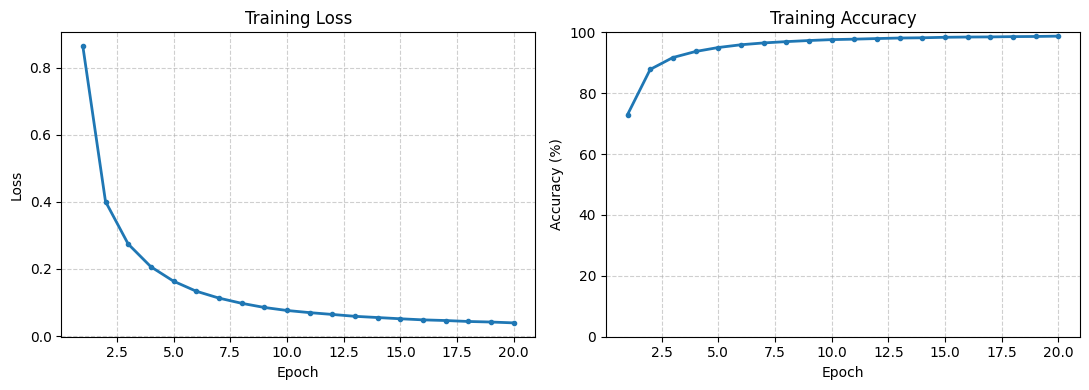

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

epochs_range = range(1, len(train_losses) + 1)

# Loss:
axes[0].plot(
    epochs_range, train_losses, marker='o', markersize=3, linewidth=2
)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Accuracy:
axes[1].plot(
    epochs_range, [a * 100 for a in train_accs],
    marker='o', markersize=3, linewidth=2
)
axes[1].set_title("Training Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()
plt.close(fig)

In [19]:
gru_model.eval()

with tc.no_grad():
    loss_sum, acc_sum, n_tokens = 0.0, 0.0, 0

    for x_batch, y_batch, lengths in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits, _ = gru_model(x_batch)

        loss = loss_fn(
            logits.reshape(-1, num_tags),
            y_batch.reshape(-1)
        )

        mask = (y_batch != pad_tag_idx)
        num_valid = mask.sum().item()

        loss_sum += loss.item() * num_valid
        acc_sum += token_accuracy(logits, y_batch, pad_tag_idx) * num_valid
        n_tokens += num_valid

    test_loss = loss_sum / n_tokens
    test_acc  = acc_sum / n_tokens

print(
    f"Test loss: {test_loss:.4f}\n"
    f"Test accuracy: {test_acc*100:.2f}%"
)

Test loss: 0.3345
Test accuracy: 92.33%


In [20]:
# Inspect one test batch
x_batch, y_batch, lengths = next(iter(test_loader))
x_batch = x_batch.to(device)
y_batch = y_batch.to(device)

gru_model.eval()
with tc.no_grad():
    logits, _ = gru_model(x_batch)
    preds = logits.argmax(dim=-1)

# Show first sentence in the batch
i = 0
L = lengths[i].item()

words = [idx_to_word[idx.item()] for idx in x_batch[i, :L].cpu()]
true_tags = [idx_to_tag[idx.item()] for idx in y_batch[i, :L].cpu()]
pred_tags = [idx_to_tag[idx.item()] for idx in preds[i, :L].cpu()]

print(
    f"{'Word':<15} {'True':<10} {'Pred':<10} {'OK?':<5}\n"
    f"{bar}"
)

for w, t, p in zip(words, true_tags, pred_tags):
    mark = "✓" if t == p else "✗"
    print(f"{w:<15} {t:<10} {p:<10} {mark:<5}")

Word            True       Pred       OK?  
----------------------------------------------------------------
<UNK>           NOUN       VERB       ✗    
corp.           NOUN       NOUN       ✓    
,               .          .          ✓    
offering        VERB       VERB       ✓    
of              ADP        ADP        ✓    
<UNK>           NUM        VERB       ✗    
common          ADJ        ADJ        ✓    
shares          NOUN       NOUN       ✓    
,               .          .          ✓    
via             ADP        ADP        ✓    
goldman         NOUN       NOUN       ✓    
,               .          .          ✓    
sachs           NOUN       NOUN       ✓    
&               CONJ       CONJ       ✓    
co.             NOUN       NOUN       ✓    
and             CONJ       CONJ       ✓    
<UNK>           NOUN       VERB       ✗    
,               .          .          ✓    
<UNK>           NOUN       VERB       ✗    
&               CONJ       CONJ       ✓    
<UNK>      

## Variants of the GRU

The **Gated Recurrent Unit (GRU)** was originally introduced as a simplified alternative to the LSTM. Over time, several architectural variants have been proposed to adapt it to different types of data or to further modify its gating mechanism.

Some commonly encountered variants include:

**1. Bidirectional GRU (BiGRU)**  
As in the LSTM, there is the bidirectional variant also here which processes the sequence in two directions simultaneously as we already discussed in the previous notebook.

**2. Convolutional GRU (ConvGRU)**  
Also in similar fashion we have the variant which replaces linear with convolutional layers like we discussed for the LSTM previously.

**3. Simplified GRU Variants (SGRU, mGRU)**  
Several studies have proposed simplified versions of the GRU that reduce the number of gates or modify the update equations to lower computational cost. For example:

- **SGRU (Simplified GRU)** removes the reset gate and uses a simpler update rule.
- **mGRU (Minimal GRU)** simplifies the gating mechanism to reduce the number of parameters while retaining much of the GRU’s performance.

**4. Other GRU-Based Variants**  
A number of additional GRU extensions have also been proposed for more specialized settings. Examples include: **Li-GRU (Light GRU)**, **AGRU / AUGRU**, and others.

## Optional Homework/Exploration

The goal of this notebook was to introduce the **Gated Recurrent Unit (GRU)** and demonstrate its ability to model sequential data on a real **many-to-many task**. While we relied on PyTorch’s built-in implementation, there are many opportunities to explore the architecture more deeply.

As an optional exercise, you may try the following extensions:

**1. Implement the GRU manually**  
Instead of using `nn.GRU`, implement the GRU cell directly from its update equations.  
This involves computing the **update gate**, **reset gate**, and **candidate hidden state**, and then updating the hidden state at each time step. Implementing the GRU from scratch is a good way to better understand how gated recurrent networks operate internally.

**2. Implement a GRU variant**  
Choose a GRU variant of your choice and implement it in PyTorch. Compare its behavior with the standard GRU used in this notebook.

**3. Improve the model**  
Try to achieve better convergeance or less trainable parameters on the POS tagging task by experimenting with the model design.

## References

1. **Cho, K. et al. (2014).**  
   *Learning Phrase Representations using RNN Encoder–Decoder for Statistical Machine Translation.*  
   https://arxiv.org/abs/1406.1078  
   — Introduces the **Gated Recurrent Unit (GRU)**.

2. **Chung, J. et al. (2014).**  
   *Empirical Evaluation of Gated Recurrent Neural Networks on Sequence Modeling.*  
   https://arxiv.org/abs/1412.3555  
   — Early empirical comparison of **GRUs and LSTMs** on sequence modeling tasks.

3. **Marcus, M., Marcinkiewicz, M., & Santorini, B. (1993).**  
   *Building a Large Annotated Corpus of English: The Penn Treebank.*  
   Computational Linguistics.  
   — The **Penn Treebank** dataset used for POS tagging.

4. **Petrov, S., Das, D., & McDonald, R. (2012).**  
   *A Universal Part-of-Speech Tagset.*  
   https://arxiv.org/abs/1104.2086  
   — Introduces the **Universal POS Tagset** used in this notebook.

5. **Zhou, G. et al. (2016).**  
   *Minimal Gated Unit for Recurrent Neural Networks.*  
   https://arxiv.org/abs/1603.09420  
   — A simplified GRU-style architecture.